# Example: Frozen Versus Online Parameters on the Realized Year and on a Scenario Ensemble
In this example, we put the two arms of the previous example into the L7a rebalancing engine. First we replay calendar year 2025 chronologically, once with the frozen archive parameters (exactly the L7a run) and once with the single index model (SIM) parameters updated online by exponentially weighted least squares (EWLS) at the half-life declared in the previous example, and score both realized paths against the static baselines. Then we build a scenario engine: many simulated futures drawn from the SIM itself, on each of which both engines run with the same rules and costs, and we read the distributional scorecard that one realized year cannot give: the fail rate, a lower quantile of terminal wealth, a tail mean, and the drawdown distribution, frozen against online, paired path by path.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Replay an engine with two parameter arms without look-ahead:__ Run the L7a engine on 2025 with frozen and with online SIM parameters, where the online parameters used on a day come from growth rates through the previous day, read the realized-path scorecard for both against the buy-and-hold baselines, and pin the episodes that separate the two paths to dates, holdings, and a counterfactual run.
> * __Build a SIM scenario generator with the right units:__ Draw daily market growth rates and independent per-asset residuals from the archive parameters, compound prices from the decision-date closes, and compute the lagged market inputs and the online updates on each simulated path exactly as on the realized one.
> * __Read a distributional scorecard honestly:__ Compute the NPV-fail rate, the lower terminal-wealth quantile at a stated level, the tail mean, and drawdown quantiles for each arm, compare the arms by paired differences, and say what a scenario ensemble drawn from the frozen model's own parameters can and cannot show.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file loads the course package [VLQuantitativeFinancePackage.jl](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/), together with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/), [LinearAlgebra](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/), [Random](https://docs.julialang.org/en/v1/stdlib/Random/), [Distributions.jl](https://juliastats.org/Distributions.jl/stable/), [JLD2.jl](https://juliaio.github.io/JLD2.jl/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/). For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for several exchange-traded funds and volatility products during that time period. This is the __training__ data: the SIM parameters in the archive were estimated from it, the signal gain is calibrated on it, and the scenario generator below is calibrated on it. We also load the __testing__ data, calendar year 2025 (`01-02-2025` until `12-31-2025`), which the engines trade through day by day.

Let's load the training data by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep only the firms with the maximum number of trading days (firms with fewer records were acquired or delisted during the period), and store the cleaned data in the `dataset::Dict{String,DataFrame}` variable:

In [2]:
dataset = let

    # initialize -
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # training data, 2014 to 2024
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has the maximum number of trading days
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Next, we do the same for the testing data by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet), and store the cleaned 2025 data in the `dataset_2025::Dict{String,DataFrame}` variable:

In [3]:
dataset_2025 = let

    # initialize -
    original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # testing data, calendar year 2025
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Finally, we load the single index model archive that the L6a estimation example saved, `SIMs-SP500-01-03-14-to-12-31-24.jld2`, [using the `JLD2.load(...)` function](https://juliaio.github.io/JLD2.jl/stable/). The archive holds, for every security fitted against SPY on the training data, the estimated intercept $\hat{\alpha}_{i}$ and beta $\hat{\beta}_{i}$ (fields `alpha`, `beta`), the residual growth-rate variance $s^{2}_{g,\varepsilon,i}$ (field `training_variance`, units: inverse years squared), and their standard errors; and, once for the whole archive, the training-period sample mean $g^{\prime}_{M}$ and sample variance $s^{2}_{g,M}$ of the market growth rate (keys `market_mean` and `market_variance`). As in the previous example, the archive was estimated on volume-weighted average prices while the engine trades and updates on close prices. We check the variance convention and store the per-ticker parameters in the `sim_parameters::Dict{String,NamedTuple}` variable and the two market moments in the `g_market_mean::Float64` and `σ²_market::Float64` variables:

In [4]:
sim_parameters, g_market_mean, σ²_market = let
    archive = JLD2.load(joinpath(_PATH_TO_DATA, "SIMs-SP500-01-03-14-to-12-31-24.jld2"));
    @assert archive["variance_convention"] == "growth_rate" # residual variances are Var(ε) in (1/years)², as in the lecture
    println("SIM archive: $(length(archive["data"])) securities fitted against $(archive["market_ticker"]) on $(archive["date_range"][1][1:10]) to $(archive["date_range"][2][1:10]); growth definition: $(archive["growth_definition"])")
    (archive["data"], archive["market_mean"], archive["market_variance"]); # return
end;

SIM archive: 424 securities fitted against SPY on 2014-01-03 to 2024-12-31; growth definition: g_t = log(S_t/S_{t-1})/Δt with S the volume-weighted average price; units 1/years; no risk-free rate subtracted


### Constants
Finally, let's specify some constants that we will use in our analysis. The engine constants are the L7a values; the EWLS constants are the values declared in the previous example. Check out the comments for details on the constants, their permissible values, units, etc.

In [5]:
Δt = (1.0/252.0); # time step (1 trading day, in years)
W₀ = 1000.0; # initial wealth W_P(0) (units: USD)
g_f = 0.041; # risk-free growth rate (units: 1/years): continuously compounded equivalent of a one-year Treasury yield of about 4.16% at the end of 2024, as in L5b, L6b, and L7a
L_short = 21; # short exponential moving average window (trading days)
L_long = 63; # long exponential moving average window (trading days)
L_growth = 10; # window of the exponential moving average of the daily market growth rate (trading days)
n_min = 0.01; # share floor for non-preferred assets (units: shares)
c = 5e-4; # transaction cost rate (USD of cost per USD of gross notional traded), 5 basis points
τ_max = 0.50; # turnover cap: largest one-way turnover allowed on one rebalance day (fraction of wealth)
d_max = 0.10; # drawdown limit: the circuit breaker moves the book to cash when wealth is this far below its peak
n_lock = 21; # trading days the engine stays in cash after the circuit breaker fires
schedule_days = 21; # calendar rebalancing: every 21 trading days (about monthly)
half_life = 63.0; # EWLS half-life t½ (trading days), declared in the previous example by walk-forward choice inside 2014 to 2024
N₀ = 63.0; # weight of the archive prior when the recursion restarts (pseudo-observations)
n_paths = 2000; # number of simulated futures in the scenario ensemble
n_days = 250; # length of each simulated future (trading days, the length of 2025)
seed = 2026; # random seed of the scenario ensemble (reproducible draws)
level = 0.05; # tail level of the lower terminal-wealth quantile, the tail mean, and the upper drawdown quantile

___

## Task 1: Firms, Prices, Market Inputs, and the Two Parameter Arms
We use the same $|\mathcal{P}| = 13$ firms as the L5b, L6b, and L7a examples, stored in the `my_list_of_tickers::Array{String,1}` array:

In [6]:
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # |𝒫| = 13 firms, as in L5b, L6b, and L7a

We pull the archive parameters for our firms, assemble the L6b inputs, and compute the static baselines of the L7a engine example exactly as it did (the long-only global minimum-variance portfolio $\mathbf{w}_{\text{GMV}}$, the tangent portfolio $\mathbf{w}_{\mathcal{T}}$ by normalizing the risky weights of one risky and risk-free solution, and the equal-weight portfolio $\mathbf{w}_{\text{eq}}$), so that the realized-path table below is a superset of L7a's. We store the parameters in the `α̂::Array{Float64,1}`, `β̂::Array{Float64,1}`, and `s²_ε::Array{Float64,1}` variables and the baselines in the `w_GMV::Array{Float64,1}`, `w_T::Array{Float64,1}`, and `w_eq::Array{Float64,1}` variables:

In [7]:
α̂, β̂, s²_ε, w_GMV, w_T, w_eq = let
    number_of_assets = length(my_list_of_tickers);

    # SIM parameters and inputs -
    α̂ = [sim_parameters[ticker].alpha for ticker ∈ my_list_of_tickers]; # intercepts (units: 1/years)
    β̂ = [sim_parameters[ticker].beta for ticker ∈ my_list_of_tickers]; # betas (dimensionless)
    s²_ε = [sim_parameters[ticker].training_variance for ticker ∈ my_list_of_tickers]; # residual variances (units: 1/years²)
    @assert all(β̂ .> 0) # the preference model raises β to a real power
    ĝ_sim = α̂ .+ β̂ .* g_market_mean; # SIM mean vector (units: 1/years)
    Σ̂_g_sim = σ²_market .* (β̂ * β̂') .+ Diagonal(s²_ε) |> Matrix; # rank one plus diagonal (units: 1/years²)

    # static baselines -
    bounds = zeros(number_of_assets, 2); bounds[:,2] .= 1.0;
    initial = (1/number_of_assets)*ones(number_of_assets);
    problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ̂_g_sim, μ = ĝ_sim, bounds = bounds, initial = initial, R = minimum(ĝ_sim)));
    w_GMV = solve(problem)["argmax"] |> w -> max.(w, 0.0) |> w -> w ./ sum(w); # long-only GMV portfolio (slack target); solver noise below zero clipped
    problem_rf = build(MyMarkowitzRiskyRiskFreePortfolioChoiceProblem, (Σ = Σ̂_g_sim, μ = ĝ_sim, bounds = bounds, initial = initial, risk_free_rate = g_f, R = 0.30));
    w_risky = solve(problem_rf)["argmax"];
    @assert sum(w_risky) > 1e-2
    w_T = max.(w_risky, 0.0) |> w -> w ./ sum(w); # tangent portfolio by normalization (ray property, L6b); solver noise clipped
    w_eq = initial;

    (α̂, β̂, s²_ε, w_GMV, w_T, w_eq); # return
end;

The engines trade at the close of each 2025 trading day. We build the 2025 close-price matrix $\mathbf{S}$ (rows are the 250 trading days of 2025, columns are the firms in the order of `my_list_of_tickers`), the SPY close series for the training period and for 2025, and the close-based daily growth rates of the firms and the market for 2025 (annualized, the growth into each 2025 close starting from the last close of 2024), which the online arm updates on. We store them in the `S_2025::Array{Float64,2}`, `spy_train::Array{Float64,1}`, `spy_2025::Array{Float64,1}`, `G_2025::Array{Float64,2}`, and `g_M_2025::Array{Float64,1}` variables:

In [8]:
S_2025, spy_train, spy_2025, G_2025, g_M_2025 = let
    for ticker ∈ vcat(my_list_of_tickers, "SPY")
        @assert dataset[ticker].timestamp == dataset["AAPL"].timestamp
        @assert dataset_2025[ticker].timestamp == dataset_2025["AAPL"].timestamp
    end
    S_train = hcat([dataset[ticker][:, :close] for ticker ∈ my_list_of_tickers]...);
    S_2025 = hcat([dataset_2025[ticker][:, :close] for ticker ∈ my_list_of_tickers]...); # N × |𝒫| close prices (USD/share)
    spy_train = dataset["SPY"][:, :close]; spy_2025 = dataset_2025["SPY"][:, :close];
    S_joined = vcat(S_train[end:end, :], S_2025); spy_joined = vcat(spy_train[end], spy_2025);
    G_2025 = log.(S_joined[2:end, :] ./ S_joined[1:end-1, :]) ./ Δt; # growth into each 2025 close (units: 1/years)
    g_M_2025 = log.(spy_joined[2:end] ./ spy_joined[1:end-1]) ./ Δt;
    println("2025: $(size(S_2025, 1)) trading days, $(size(S_2025, 2)) firms; first day $(Date(dataset_2025["AAPL"][1, :timestamp])), last day $(Date(dataset_2025["AAPL"][end, :timestamp]))")
    (S_2025, spy_train, spy_2025, G_2025, g_M_2025); # return
end;

2025: 250 trading days, 13 firms; first day 2025-01-02, last day 2025-12-31


Three pieces of machinery are shared by the realized replay and by every simulated future, so we write them once as functions. The __lagged market inputs__ take a training SPY close series and a continuation (2025, or a simulated path), calibrate the signal gain $G$ on the training portion, compute the crossover signal $\xi_{t}$ and the recent market growth $\tilde{g}_{M,t}$ on the joined series with the L7a windows, and return them shifted one day, so that the values used on continuation day $t$ come from closes through day $t-1$. The __online parameter paths__ restart the EWLS recursion from the archive prior with weight $N_{0}$ (seeded through the archive's training market moments) and return, for each day $t$ of a growth-rate matrix, the intercept and beta that stood before day $t$'s observation was folded in, so that the parameters used on day $t$ come from growth rates through day $t-1$. The __preference weights__ apply the L7a model $\gamma_{i}(t) = \tanh(\alpha_{i}/\beta_{i}^{\xi_{t}} + \beta_{i}^{1-\xi_{t}}\tilde{g}_{M,t})$ with the stated rule for a non-positive beta (assignment to the non-preferred set). Let's define them:

In [9]:
function lagged_market_inputs(spy_train::AbstractVector, spy_path::AbstractVector; L_short::Int = 21, L_long::Int = 63, L_growth::Int = 10, Δt::Float64 = 1/252)
    N_train = length(spy_train); N = length(spy_path);
    S̄_short_train = compute_ema(spy_train, L_short); S̄_long_train = compute_ema(spy_train, L_long);
    t₀ = L_short + L_long;
    G = 1.0/quantile(abs.(S̄_short_train[t₀:end] ./ S̄_long_train[t₀:end] .- 1.0), 0.99); # gain from the training portion only
    spy_all = vcat(spy_train, spy_path);
    S̄_short = compute_ema(spy_all, L_short); S̄_long = compute_ema(spy_all, L_long);
    ξ_all = -G .* (S̄_short ./ S̄_long .- 1.0);
    g_M_all = log.(spy_all[2:end] ./ spy_all[1:end-1]) ./ Δt; g̃_all = compute_ema(g_M_all, L_growth);
    ξ_lag = [ξ_all[N_train + t - 1] for t ∈ 1:N]; g̃_M_lag = [g̃_all[N_train + t - 2] for t ∈ 1:N]; # day t uses closes through day t−1
    return (ξ = ξ_lag, g̃_M = g̃_M_lag, G = G)
end

function online_parameter_paths(G_path::AbstractMatrix, g_M_path::AbstractVector, α₀::AbstractVector, β₀::AbstractVector, σ_ε₀::AbstractVector; half_life::Float64 = 63.0, N₀::Float64 = 63.0, market_mean::Float64 = 0.0, market_variance::Float64 = 1.0)
    N, number_of_assets = size(G_path);
    α_online = zeros(N, number_of_assets); β_online = zeros(N, number_of_assets);
    for k ∈ 1:number_of_assets
        state = ewls_init(α₀[k], β₀[k], σ_ε₀[k]; half_life = half_life, prior_weight = N₀, market_mean = market_mean, market_variance = market_variance); # the archive prior
        for t ∈ 1:N
            α_online[t, k], β_online[t, k] = state.α, state.β; # used on day t: growth rates through day t−1
            ewls_update!(state, G_path[t, k], g_M_path[t]); # fold in the growth into the close of day t
        end
    end
    return (α = α_online, β = β_online)
end

preference_weights(α::AbstractVector, β::AbstractVector, ξ::Float64, g̃::Float64) = [β[i] > 0 ? tanh(α[i]/β[i]^ξ + β[i]^(1 - ξ)*g̃) : 0.0 for i ∈ eachindex(α)]; # non-positive β: non-preferred (L7a rule)

We now compute the two arms for 2025: the lagged inputs, the online paths (asserting that on the first day of 2025 they equal the archive), and the preference-weight matrices $\boldsymbol{\Gamma}$ (rows are 2025 days, columns are firms) for the frozen and the online arm. We store them in the `ξ_lag::Array{Float64,1}`, `g̃_M_lag::Array{Float64,1}`, `Γ_frozen::Array{Float64,2}`, and `Γ_online::Array{Float64,2}` variables:

In [10]:
ξ_lag, g̃_M_lag, Γ_frozen, Γ_online = let
    N = size(S_2025, 1);
    inputs = lagged_market_inputs(spy_train, spy_2025; L_short = L_short, L_long = L_long, L_growth = L_growth, Δt = Δt);
    online = online_parameter_paths(G_2025, g_M_2025, α̂, β̂, sqrt.(s²_ε); half_life = half_life, N₀ = N₀, market_mean = g_market_mean, market_variance = σ²_market);
    @assert all(online.α[1, :] .== α̂) && all(online.β[1, :] .== β̂) # the online arm starts where the frozen arm stands
    Γ_frozen = hcat([preference_weights(α̂, β̂, inputs.ξ[t], inputs.g̃_M[t]) for t ∈ 1:N]...)' |> Matrix;
    Γ_online = hcat([preference_weights(online.α[t, :], online.β[t, :], inputs.ξ[t], inputs.g̃_M[t]) for t ∈ 1:N]...)' |> Matrix;
    println("gain G = $(round(inputs.G, digits=2)); empty-basket days in 2025: frozen $(count([all(Γ_frozen[t, :] .<= 0) for t ∈ 1:N])), online $(count([all(Γ_online[t, :] .<= 0) for t ∈ 1:N])); the two arms classify at least one firm differently on $(count([any((Γ_frozen[t, :] .> 0) .!= (Γ_online[t, :] .> 0)) for t ∈ 1:N])) days")
    (inputs.ξ, inputs.g̃_M, Γ_frozen, Γ_online); # return
end;

gain G = 21.23; empty-basket days in 2025: frozen 57, online 12; the two arms classify at least one firm differently on 101 days


___

## Task 2: Chronological Replay of 2025, Frozen Versus Online
The engine is [the `run_utility_engine(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.run_utility_engine) of the course package, exactly as in L7a: the self-financing account, next-bar execution, the reallocation schedule $\mathcal{R}$, the turnover cap $\tau_{\max}$, and the drawdown limit $d_{\max}$ with its lock. The two arms differ in one thing only: the target function reads its preference weights from `Γ_frozen` or from `Γ_online`; the Cobb–Douglas allocation [via `allocate_cobb_douglas(...)`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.allocate_cobb_douglas), the rules, the costs, and the prices are the same. We run both arms on the monthly schedule (the L7a headline configuration) and on the daily schedule, and the four buy-and-hold baselines (GMV, tangent, equal weight, SPY) through the same engine, and collect the runs in the `runs::Dict{String,NamedTuple}` variable:

In [11]:
runs = let
    N = size(S_2025, 1);
    R_monthly = collect(1:schedule_days:N); R_daily = collect(1:N);
    target(Γ) = (t, state) -> allocate_cobb_douglas(state.prices, Γ[t, :], state.wealth; epsilon = n_min).dollars ./ state.wealth; # risky weights of wealth from the day's preference weights
    rules = (W0 = W₀, cost_rate = c, turnover_cap = τ_max, drawdown_limit = d_max, reentry_days = n_lock, g_f = g_f, Δt = Δt);
    runs = Dict{String, NamedTuple}();
    runs["frozen, monthly"] = run_utility_engine(S_2025, target(Γ_frozen); rebalance_days = R_monthly, rules...);
    runs["online, monthly"] = run_utility_engine(S_2025, target(Γ_online); rebalance_days = R_monthly, rules...);
    runs["frozen, daily"] = run_utility_engine(S_2025, target(Γ_frozen); rebalance_days = R_daily, rules...);
    runs["online, daily"] = run_utility_engine(S_2025, target(Γ_online); rebalance_days = R_daily, rules...);
    runs["GMV (buy and hold)"] = run_utility_engine(S_2025, (t, state) -> w_GMV; W0 = W₀, rebalance_days = [1], cost_rate = c, g_f = g_f, Δt = Δt);
    runs["tangent (buy and hold)"] = run_utility_engine(S_2025, (t, state) -> w_T; W0 = W₀, rebalance_days = [1], cost_rate = c, g_f = g_f, Δt = Δt);
    runs["equal weight (buy and hold)"] = run_utility_engine(S_2025, (t, state) -> w_eq; W0 = W₀, rebalance_days = [1], cost_rate = c, g_f = g_f, Δt = Δt);
    runs["SPY (buy and hold)"] = run_utility_engine(reshape(spy_2025, :, 1), (t, state) -> [1.0]; W0 = W₀, rebalance_days = [1], cost_rate = c, g_f = g_f, Δt = Δt);
    runs; # return
end;

We score every run on the realized 2025 path [using the `realized_scorecard(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.realized_scorecard) with the L7a columns: terminal wealth, portfolio NPV against the risk-free baseline, maximum drawdown, realized growth rate, annualized realized Sharpe ratio, total one-way turnover, total cost, and the number of circuit-breaker interventions. The frozen monthly row must reproduce the L7a engine example to the cent. We store the table in the `scorecard::DataFrame` variable:

In [12]:
scorecard = let
    order = ["frozen, monthly", "online, monthly", "frozen, daily", "online, daily", "GMV (buy and hold)", "tangent (buy and hold)", "equal weight (buy and hold)", "SPY (buy and hold)"];
    df = DataFrame(run = String[], W_T = Float64[], NPV = Float64[], max_drawdown = Float64[], growth = Float64[], sharpe = Float64[], turnover = Float64[], cost = Float64[], interventions = Int[]);
    for name ∈ order
        r = runs[name];
        sc = realized_scorecard(r.wealth; g_f = g_f, Δt = Δt, turnover = r.turnover, cost = r.cost, interventions = r.interventions);
        push!(df, (run = name, W_T = round(sc.terminal, digits=2), NPV = round(sc.npv, digits=2), max_drawdown = round(sc.max_drawdown, digits=4),
            growth = round(sc.realized_growth, digits=4), sharpe = round(sc.realized_sharpe, digits=3), turnover = round(sc.total_turnover, digits=3), cost = round(sc.total_cost, digits=2), interventions = sc.interventions));
    end
    @assert isapprox(df[1, :W_T], 1533.3; atol = 0.01) # the frozen monthly arm is the L7a run
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, table_format = TextTableFormat(borders = text_table_borders__compact))
    df; # return
end;

 ----------------------------- --------- --------- -------------- --------- --------- ---------- --------- ---------------
                          run       W_T       NPV   max_drawdown    growth    sharpe   turnover      cost   interventions 
                       String   Float64   Float64        Float64   Float64   Float64    Float64   Float64           Int64 
 ----------------------------- --------- --------- -------------- --------- --------- ---------- --------- ---------------
              frozen, monthly    1533.3    472.18         0.0898    0.4308     2.529      2.108       1.9               0
              online, monthly   1331.09    278.04         0.1009    0.2883     1.266      4.613      3.49               1
                frozen, daily   1399.51    343.72          0.108    0.3388     1.705      45.69     38.86               1
                online, daily   1259.09     208.9         0.2271    0.2322      0.86     44.034     38.65               2
           GMV (buy 

On the year that happened, updating the parameters __hurt__: the online monthly engine ended at 1.33 times its initial wealth against 1.53 for the frozen engine, with twice the turnover, a slightly deeper drawdown, and one firing of the circuit breaker (the frozen engine never fired it); on the daily schedule the gap is similar. Where did the gap open? A wealth plot suggests two episodes, and rather than narrate them from the picture we pin them to dates, wealth, holdings, and drawdown for both monthly arms: the last day of March, the April trough of the online arm, the day of the year's peak, November 20, and the last day of the year. We also run one __counterfactual__, the online monthly engine with the circuit breaker disabled, to measure what the breaker's firing cost on this path (a rerun, not a narrative). We store the table in the `events::DataFrame` variable:

In [13]:
events = let
    dates = Date.(dataset_2025["AAPL"].timestamp); N = length(dates); k_JNJ = findfirst(==("JNJ"), my_list_of_tickers);
    r_f = runs["frozen, monthly"]; r_o = runs["online, monthly"];
    peak_day = argmax(r_o.wealth[2:end]); trough_day = argmin(r_o.wealth[61:80]) + 59; # the online arm's peak day and its April trough (wealth row i is day i−1; rows 61 to 80 are days 60 to 79)
    marks = [("March 31", findfirst(==(Date(2025, 3, 31)), dates)), ("April trough (online)", trough_day), ("May 5", findfirst(==(Date(2025, 5, 5)), dates)), ("peak day (online)", peak_day), ("November 20", findfirst(==(Date(2025, 11, 20)), dates)), ("December 31", N)];
    df = DataFrame(event = String[], date = Date[], W_frozen = Float64[], W_online = Float64[], gap = Float64[], JNJ_weight_online = Float64[], exposure_online = Float64[], drawdown_frozen = Float64[], drawdown_online = Float64[], online_locked = Bool[]);
    peaks_f = accumulate(max, r_f.wealth); peaks_o = accumulate(max, r_o.wealth);
    for (label, t) ∈ marks
        push!(df, (event = label, date = dates[t], W_frozen = round(r_f.wealth[t+1], digits=1), W_online = round(r_o.wealth[t+1], digits=1), gap = round(r_o.wealth[t+1] - r_f.wealth[t+1], digits=1),
            JNJ_weight_online = round(r_o.weights[t+1, k_JNJ], digits=3), exposure_online = round(dot(r_o.shares[t+1, :], S_2025[t, :])/r_o.wealth[t+1], digits=3),
            drawdown_frozen = round(1 - r_f.wealth[t+1]/peaks_f[t+1], digits=4), drawdown_online = round(1 - r_o.wealth[t+1]/peaks_o[t+1], digits=4), online_locked = r_o.locked[t]));
    end
    pretty_table(df[:, 1:6], backend = :text, fit_table_in_display_horizontally = false, table_format = TextTableFormat(borders = text_table_borders__compact))
    pretty_table(df[:, [1, 7, 8, 9, 10]], backend = :text, fit_table_in_display_horizontally = false, table_format = TextTableFormat(borders = text_table_borders__compact))

    # the online arm's cash interval after the breaker, and the counterfactual with the breaker disabled -
    locked_days = findall(r_o.locked); cash_days = findall(t -> dot(r_o.shares[t+1, :], S_2025[t, :]) < 1e-9, 1:N);
    R_monthly = collect(1:schedule_days:N);
    r_nb = run_utility_engine(S_2025, (t, state) -> allocate_cobb_douglas(state.prices, Γ_online[t, :], state.wealth; epsilon = n_min).dollars ./ state.wealth; W0 = W₀, rebalance_days = R_monthly, cost_rate = c, turnover_cap = τ_max, drawdown_limit = 1.0, g_f = g_f, Δt = Δt);
    println("online monthly: breaker fired on day $(locked_days[1]) ($(dates[locked_days[1]])), locked through day $(locked_days[end]) ($(dates[locked_days[end]])); scheduled rebalance days after the firing: $(filter(>(locked_days[1]), R_monthly)) (inside the lock), so the book stayed in cash from day $(cash_days[1]) to day $(cash_days[end]) ($(dates[cash_days[end]]))")
    println("counterfactual, online monthly with the breaker disabled: W_T = $(round(r_nb.wealth[end], digits=2)) against $(round(r_o.wealth[end], digits=2)) with it and $(round(r_f.wealth[end], digits=2)) frozen; the firing accounts for $(round(r_nb.wealth[end] - r_o.wealth[end], digits=1)) of the $(round(r_f.wealth[end] - r_o.wealth[end], digits=1)) gap")
    df; # return
end;

 ----------------------- ------------ ---------- ---------- --------- -------------------
                  event         date   W_frozen   W_online       gap   JNJ_weight_online 
                 String         Date    Float64    Float64   Float64             Float64 
 ----------------------- ------------ ---------- ---------- --------- -------------------
               March 31   2025-03-31     1008.4     1043.9      35.5               0.984
  April trough (online)   2025-04-10     1008.1      950.6     -57.5               0.476
                  May 5   2025-05-05     1012.6      973.0     -39.6               0.485
      peak day (online)   2025-11-12     1517.5     1474.0     -43.5               0.009
            November 20   2025-11-20     1381.2     1325.3     -56.0                 0.0
            December 31   2025-12-31     1533.3     1331.1    -202.2                 0.0
 ----------------------- ------------ ---------- ---------- --------- -------------------
 ---------------

The table separates two visible episodes from the estimator itself, and the counterfactual measures the second. In February and March the frozen thresholds kept the basket empty (the frozen book held the floors plus cash on all of its 50 such days before May), while the online intercept of JNJ had risen enough to put JNJ, alone, into the online basket: the online engine moved into it under the turnover cap, held 98% of its wealth in JNJ on March 31, and was ahead by 3.5%; when the market fell in early April JNJ fell with it, and at its April 10 trough the online arm, still half in JNJ under the cap, was 8.9% below its March 31 wealth and about 58 dollars behind the frozen arm; the gap narrowed to about 40 dollars by May and stayed between 40 and 56 dollars until November 20. Then both arms peaked on the same day, November 12, and drew down together: the frozen engine by 9.0% on November 20, under the limit, and the online engine, from a lower peak and slightly different weights, by 10.1%, over it. The breaker liquidated the online book, the lock covered the December rebalance day, and with no scheduled day left in the year the book stayed in cash through December, missing the rally the frozen engine caught; with the breaker disabled the same online engine ends the year at 1.50, so the firing accounts for about 166 of the 202 dollars of the final gap. Read carefully, neither episode is "the rule, not the estimator": the online estimates changed the holdings, the changed holdings produced a path that crossed the breaker's threshold by a tenth of a percent, and the discontinuous rule amplified that difference into a quarter of the year in cash. A single path cannot separate estimation, allocation, and the rule cleanly; a counterfactual can measure one of them, and this one says the rule's discontinuity did most of the damage on this path. Neither arm's number is a probability. `Unhide` the code block below to see the scaled wealth of the two arms on both schedules with the baselines through 2025 (the shaded stretch is the interval the online monthly book spent in cash after the breaker fired):

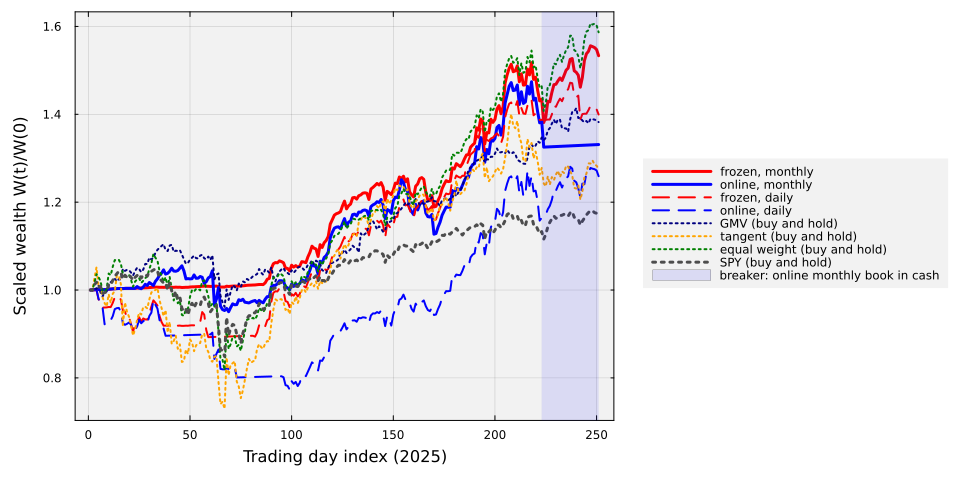

In [14]:
let
    styles = [("frozen, monthly", :red, :solid, 3), ("online, monthly", :blue, :solid, 3), ("frozen, daily", :red, :dash, 2), ("online, daily", :blue, :dash, 2),
        ("GMV (buy and hold)", :navy, :dot, 2), ("tangent (buy and hold)", :orange, :dot, 2), ("equal weight (buy and hold)", :green, :dot, 2), ("SPY (buy and hold)", :gray30, :dot, 3)];
    p = plot();
    for (name, color, style, width) ∈ styles
        plot!(p, runs[name].wealth ./ W₀, lw = width, c = color, ls = style, label = name)
    end
    r = runs["online, monthly"]; N = size(S_2025, 1);
    fired = findfirst(r.locked);
    if fired !== nothing
        cash_days = filter(t -> t >= fired && dot(r.shares[t+1, :], S_2025[t, :]) < 1e-9, 1:N); # the whole interval in cash after the breaker, lock plus the wait for a scheduled day
        vspan!(p, [cash_days[1], cash_days[end] + 1], c = :blue, alpha = 0.10, label = "breaker: online monthly book in cash")
    end
    plot!(p, xlabel = "Trading day index (2025)", ylabel = "Scaled wealth W(t)/W(0)",
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :outerright, size = (960, 480),
        left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)
end

___

## Task 3: The SIM Scenario Generator
One year is one draw. To ask how the two arms compare across many years the market __could__ have produced, we need a generator of futures, and the natural one is the model the engine already carries. The SIM says that on each day the market's growth rate is drawn around its mean, and each asset's growth rate is its intercept plus its beta times the market's growth plus an independent residual. Calibrated on the training archive, the generator for one future of $N$ trading days from a decision date is:

> __SIM scenario generator (units stated):__ For $t = 1,\ldots,N$, draw the daily market growth rate and the daily residuals independently across days and across assets:
> $$
g_{M,t}\sim\mathcal{N}\left(g^{\prime}_{M},\,s^{2}_{g,M}\right),\qquad
\varepsilon_{i,t}\sim\mathcal{N}\left(0,\,s^{2}_{g,\varepsilon,i}\right),\qquad
g_{i,t} = \hat{\alpha}_{i} + \hat{\beta}_{i}\,g_{M,t} + \varepsilon_{i,t}
$$
> all in inverse years, and compound the closes from the decision-date closes: $S_{M}(t) = S_{M}(t-1)\,e^{g_{M,t}\Delta{t}}$ and $S_{i}(t) = S_{i}(t-1)\,e^{g_{i,t}\Delta{t}}$. Because $g_{M,t}$ is drawn once per day and shared by every asset, the assets co-move through the market term exactly as the SIM covariance $s^{2}_{g,M}\hat{\boldsymbol{\beta}}\hat{\boldsymbol{\beta}}^{\top} + \hat{\mathbf{D}}_{g}$ says they do; the residuals are the only other source of variation, so the generator has no residual correlation, no heavy tails, and no volatility clustering (L3a, L6a).

On the units: the SIM is a model of __daily growth rates in annualized units__, so we draw those and let the time step enter once, in the exponent $g\Delta{t}$ that turns a growth rate into a one-day log return; the log return of the market over one day therefore has mean $g^{\prime}_{M}\Delta{t}$ and variance $s^{2}_{g,M}\Delta{t}^{2}$, the L4b GBM step with the L5a conversion between growth-rate and log-return units. The decision date is the last trading day of 2024, so every future starts from the same closes 2025 started from and runs for the same 250 days. Two honest notes before we draw: the archive's moments come from VWAP growth rates, which are smoother than close-to-close ones (a market variance of 4.6 against 7.5 per year squared, previous example), so these futures are calmer than close-to-close history; and the market's mean of $g^{\prime}_{M} = 0.106$ per year is the training decade's, not a forecast. Let's write the generator as a function that takes a random number generator, so that the ensemble is reproducible from `seed`:

In [15]:
function simulate_sim_future(rng::AbstractRNG, S₀::AbstractVector, spy₀::Float64, α::AbstractVector, β::AbstractVector, s_ε::AbstractVector, g_M_mean::Float64, g_M_variance::Float64, N::Int, Δt::Float64)
    g_M = g_M_mean .+ sqrt(g_M_variance) .* randn(rng, N); # daily market growth rates (units: 1/years), one draw per day shared by all assets
    E = randn(rng, N, length(α)) .* transpose(s_ε); # independent residuals, one per asset per day (units: 1/years)
    G = transpose(α) .+ g_M * transpose(β) .+ E; # N × |𝒫| asset growth rates from the SIM (units: 1/years)
    spy = spy₀ .* exp.(cumsum(g_M) .* Δt); # closes by compounding the one-day log returns g Δt from the decision-date close
    S = transpose(S₀) .* exp.(cumsum(G, dims = 1) .* Δt);
    return (g_M = g_M, G = G, spy = spy, S = S)
end;

Before running engines on it, we check the generator: on one long draw (fifty thousand days) the sample mean and variance of the simulated market growth rate should reproduce the archive's within sampling error (the standard error of the mean is about 0.01 per year at that length), the fitted OLS parameters of a simulated asset should reproduce its archive values within the standard errors, and the simulated one-year SPY terminal values should bracket what 2025 delivered (SPY ended 2025 at 1.164 times its last 2024 close). Do we see what we expect?

In [16]:
let
    rng = MersenneTwister(seed);
    S_train = hcat([dataset[ticker][:, :close] for ticker ∈ my_list_of_tickers]...);
    future = simulate_sim_future(rng, S_train[end, :], spy_train[end], α̂, β̂, sqrt.(s²_ε), g_market_mean, σ²_market, 50_000, Δt); # one long draw
    k = findfirst(==("NVDA"), my_list_of_tickers);
    X̂ = hcat(ones(50_000), future.g_M); θ = X̂ \ future.G[:, k];
    println("simulated market growth: mean $(round(mean(future.g_M), digits=3)) 1/yr (archive $(round(g_market_mean, digits=3))), variance $(round(var(future.g_M), digits=2)) 1/yr² (archive $(round(σ²_market, digits=2)))")
    println("NVDA refit on the simulated path: α = $(round(θ[1], digits=3)) (archive $(round(α̂[k], digits=3)) ± $(round(sim_parameters["NVDA"].alpha_SE, digits=3))), β = $(round(θ[2], digits=3)) (archive $(round(β̂[k], digits=3)) ± $(round(sim_parameters["NVDA"].beta_SE, digits=3)))")
    terminals = [simulate_sim_future(rng, S_train[end, :], spy_train[end], α̂, β̂, sqrt.(s²_ε), g_market_mean, σ²_market, n_days, Δt).spy[end]/spy_train[end] for _ ∈ 1:n_paths];
    println("simulated one-year SPY price relative: median $(round(median(terminals), digits=3)), 5% to 95% $(round(quantile(terminals, 0.05), digits=3)) to $(round(quantile(terminals, 0.95), digits=3)); realized 2025: $(round(spy_2025[end]/spy_train[end], digits=3))")
end

simulated market growth: mean 0.095 1/yr (archive 0.106), variance 4.58 1/yr² (archive 4.6)
NVDA refit on the simulated path: α = 0.351 (archive 0.347 ± 0.093), β = 1.732 (archive 1.749 ± 0.043)
simulated one-year SPY price relative: median 1.114, 5% to 95% 0.891 to 1.384; realized 2025: 1.164


The generator reproduces its own calibration to within sampling error, and the realized 2025 market sits inside its central range. On each simulated future the two engines will see exactly what they saw on the realized year: the lagged market inputs computed on the joined series (training SPY closes, then the simulated SPY closes) with the same gain and lag, and, for the online arm, the EWLS recursion restarted from the archive prior and updated on the simulated growth rates with the same one-day shift. The frozen arm's parameters are the generator's own parameters, exactly. That is the __same-generator__ situation of L5b: under this generator there are no parameter changes for the online estimates to detect, so their movements are responses to sampling noise; what those movements do to this particular policy's wealth is an empirical question (a nonlinear policy with a breaker is not proved optimal at the true parameters, so noise could in principle help or hurt), and the ensemble measures it. What the ensemble cannot measure is the benefit of updating when the world drifts, because nothing in it drifts.
___

## Task 4: The Ensemble and the Distributional Scorecard
We now draw `n_paths` futures of `n_days` days from `seed`, and on each we run the frozen monthly engine, the online monthly engine, and SPY bought and held on the simulated market path (a market reference under the same generator), all through the same engine with the same rules and costs. From each run we keep the terminal wealth $W_{\mathcal{P}}(T)$ and the maximum drawdown along the path, plus the number of empty-basket days and breaker firings, and store them in the `ensemble::NamedTuple` variable (vectors indexed by path):

In [17]:
ensemble = let
    rng = MersenneTwister(seed);
    S_train = hcat([dataset[ticker][:, :close] for ticker ∈ my_list_of_tickers]...);
    N = n_days; R_monthly = collect(1:schedule_days:N);
    rules = (W0 = W₀, rebalance_days = R_monthly, cost_rate = c, turnover_cap = τ_max, drawdown_limit = d_max, reentry_days = n_lock, g_f = g_f, Δt = Δt);
    target(Γ) = (t, state) -> allocate_cobb_douglas(state.prices, Γ[t, :], state.wealth; epsilon = n_min).dollars ./ state.wealth;
    maximum_drawdown(w) = maximum(1 .- w ./ accumulate(max, w));
    W_frozen = zeros(n_paths); W_online = zeros(n_paths); W_spy = zeros(n_paths);
    D_frozen = zeros(n_paths); D_online = zeros(n_paths); D_spy = zeros(n_paths);
    empty_frozen = zeros(Int, n_paths); empty_online = zeros(Int, n_paths); fired_frozen = zeros(Int, n_paths); fired_online = zeros(Int, n_paths);
    for p ∈ 1:n_paths
        future = simulate_sim_future(rng, S_train[end, :], spy_train[end], α̂, β̂, sqrt.(s²_ε), g_market_mean, σ²_market, N, Δt);
        inputs = lagged_market_inputs(spy_train, future.spy; L_short = L_short, L_long = L_long, L_growth = L_growth, Δt = Δt); # same lag as on the realized year
        online = online_parameter_paths(future.G, future.g_M, α̂, β̂, sqrt.(s²_ε); half_life = half_life, N₀ = N₀, market_mean = g_market_mean, market_variance = σ²_market); # restarted from the archive prior
        Γ_f = hcat([preference_weights(α̂, β̂, inputs.ξ[t], inputs.g̃_M[t]) for t ∈ 1:N]...)' |> Matrix;
        Γ_o = hcat([preference_weights(online.α[t, :], online.β[t, :], inputs.ξ[t], inputs.g̃_M[t]) for t ∈ 1:N]...)' |> Matrix;
        r_f = run_utility_engine(future.S, target(Γ_f); rules...);
        r_o = run_utility_engine(future.S, target(Γ_o); rules...);
        r_s = run_utility_engine(reshape(future.spy, :, 1), (t, state) -> [1.0]; W0 = W₀, rebalance_days = [1], cost_rate = c, g_f = g_f, Δt = Δt);
        W_frozen[p], W_online[p], W_spy[p] = r_f.wealth[end], r_o.wealth[end], r_s.wealth[end];
        D_frozen[p], D_online[p], D_spy[p] = maximum_drawdown(r_f.wealth), maximum_drawdown(r_o.wealth), maximum_drawdown(r_s.wealth);
        empty_frozen[p] = count([all(Γ_f[t, :] .<= 0) for t ∈ 1:N]); empty_online[p] = count([all(Γ_o[t, :] .<= 0) for t ∈ 1:N]);
        fired_frozen[p] = r_f.interventions; fired_online[p] = r_o.interventions;
    end
    println("$(n_paths) futures of $(N) days; empty-basket days per future: frozen $(round(mean(empty_frozen), digits=1)), online $(round(mean(empty_online), digits=1)); breaker firings per future: frozen $(round(mean(fired_frozen), digits=2)), online $(round(mean(fired_online), digits=2)); fraction of futures with at least one firing: frozen $(round(mean(fired_frozen .> 0), digits=3)), online $(round(mean(fired_online .> 0), digits=3))")
    (W_frozen = W_frozen, W_online = W_online, W_spy = W_spy, D_frozen = D_frozen, D_online = D_online, D_spy = D_spy); # return
end;

2000 futures of 250 days; empty-basket days per future: frozen 84.2, online 62.4; breaker firings per future: frozen 0.73, online 0.98; fraction of futures with at least one firing: frozen 0.634, online 0.776


The distributional scorecard is [the `ensemble_scorecard(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.ensemble_scorecard) of the course package. From the terminal wealths and drawdowns of $n$ paths at horizon $T = N\Delta{t}$ years it computes: the median terminal wealth and median NPV; the __fail rate__, the fraction of paths whose terminal wealth falls below the risk-free baseline $W_{\mathcal{P}}(0)e^{g_{f}T}$ (the fraction with negative NPV); the __lower quantile__ of terminal wealth at `level`, taken as the order statistic $W_{(k)}$ with $k = \lceil\,\text{level}\cdot n\,\rceil$ so that at least a fraction `level` of the paths end at or below it; the __tail mean__, the average of the $k$ smallest terminal wealths (the mean of the worst 5% of outcomes); and for the drawdown, its median and its upper quantile at the same level (the $k$-th largest drawdown). We tabulate the three runs in the `distributional_scorecard::DataFrame` variable:

In [18]:
distributional_scorecard = let
    T = n_days*Δt;
    df = DataFrame(run = String[], median_W_T = Float64[], fail_rate = Float64[], lower_quantile = Float64[], tail_mean = Float64[], median_drawdown = Float64[], drawdown_quantile = Float64[]);
    for (name, W, D) ∈ [("frozen, monthly", ensemble.W_frozen, ensemble.D_frozen), ("online, monthly", ensemble.W_online, ensemble.D_online), ("SPY (buy and hold)", ensemble.W_spy, ensemble.D_spy)]
        sc = ensemble_scorecard(W, D; W0 = W₀, g_f = g_f, horizon = T, level = level);
        push!(df, (run = name, median_W_T = round(sc.median_terminal, digits=1), fail_rate = round(sc.fail_rate, digits=3), lower_quantile = round(sc.lower_quantile, digits=1), tail_mean = round(sc.tail_mean, digits=1), median_drawdown = round(sc.median_drawdown, digits=3), drawdown_quantile = round(sc.drawdown_quantile, digits=3)));
    end
    println("risk-free baseline W_P(0) e^{g_f T} = $(round(W₀*exp(g_f*T), digits=1)) USD; level $(level) with $(n_paths) paths uses the order statistic k = $(max(1, ceil(Int, level*n_paths)))")
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, table_format = TextTableFormat(borders = text_table_borders__compact))
    df; # return
end;

risk-free baseline W_P(0) e^{g_f T} = 1041.5 USD; level 0.05 with 2000 paths uses the order statistic k = 100
 -------------------- ------------ ----------- ---------------- ----------- ----------------- -------------------
                 run   median_W_T   fail_rate   lower_quantile   tail_mean   median_drawdown   drawdown_quantile 
              String      Float64     Float64          Float64     Float64           Float64             Float64 
 -------------------- ------------ ----------- ---------------- ----------- ----------------- -------------------
     frozen, monthly       1138.0       0.273            927.0       887.8             0.106               0.165
     online, monthly       1124.6       0.314            901.3       864.0             0.113               0.182
  SPY (buy and hold)       1113.1       0.296            887.1       837.4             0.105               0.199
 -------------------- ------------ ----------- ---------------- ----------- ----------------- -

Read the frozen row first, because it is the same engine that made 1.53 on the realized 2025: under futures drawn from its own parameters it has a median terminal wealth of about 1.14 times initial wealth, fails to beat the risk-free baseline on roughly a quarter of the paths, and its 5% lower quantile is below the initial wealth. The realized 2025 was a good draw for it, not a typical one. Its median drawdown sits right at the breaker's limit, because a 10% drawdown of a portfolio concentrated in high-beta names is an ordinary event under this generator, and the breaker fires on 63% of the futures (the fraction is printed above). The online row is a little worse on every column, and SPY bought and held is close to both. Because both engines ran on the __same__ futures, the comparison that matters is paired: for each path, the online terminal wealth minus the frozen one. Pairing holds the market and residual draws fixed across the two policies (it does not cancel them algebraically, since the policies are nonlinear in the path), which removes most of the path-to-path noise from the comparison and leaves the policy contrast. `Unhide` the code block below to see the paired differences and their summary:

paired difference, online − frozen terminal wealth (USD): mean -12.3, median -11.0, standard deviation 140.4, 5% to 95% -242.5 to 226.6; the online arm ended higher on 43.8% of the futures


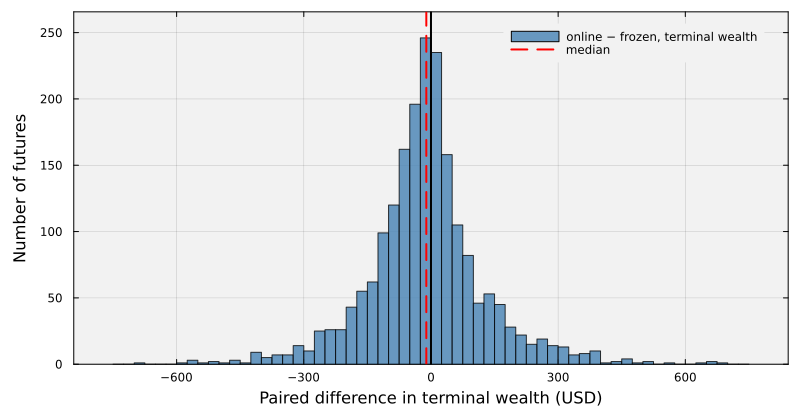

In [19]:
let
    d = ensemble.W_online .- ensemble.W_frozen;
    println("paired difference, online − frozen terminal wealth (USD): mean $(round(mean(d), digits=1)), median $(round(median(d), digits=1)), standard deviation $(round(std(d), digits=1)), 5% to 95% $(round(quantile(d, 0.05), digits=1)) to $(round(quantile(d, 0.95), digits=1)); the online arm ended higher on $(round(100*mean(d .> 0), digits=1))% of the futures")
    edges = -750:25:750; counts = [count(e .<= d .< e + 25) for e ∈ edges[1:end-1]];
    p = bar(edges[1:end-1] .+ 12.5, counts, bar_width = 25, c = :steelblue, alpha = 0.8, lc = :black, label = "online − frozen, terminal wealth", xlabel = "Paired difference in terminal wealth (USD)", ylabel = "Number of futures");
    vline!(p, [0.0], lw = 2, c = :black, label = ""); vline!(p, [median(d)], lw = 2, ls = :dash, c = :red, label = "median");
    plot!(p, ylim = (0, 1.08*maximum(counts)), bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topright, size = (800, 420), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
end

The paired difference is centered slightly below zero with a spread of well over a hundred dollars on a thousand, and the online arm ends ahead on 44% of the futures, materially below half with two thousand paths: on a future in which nothing has changed, the online arm's noise costs it a little at the median. That is the observed cost of updating under a generator with no drift for the estimator to learn.
___

## Task 5: An Honest Reading
Three statements bound what these numbers mean, and they belong next to the table rather than in a footnote.

* __This is a scenario engine, not a validation.__ The futures are drawn from a SIM calibrated on 2014 to 2024, with Gaussian daily draws, independent residuals, constant parameters, and VWAP-smoothed moments; nothing in it was checked against how 2025 unfolded, and the L3a stylized facts (heavy tails, clustered volatility) are absent by construction. The scorecard says how the two arms behave under those assumptions. Turning such comparisons into pass-or-fail deployment gates, with the frozen engine as the baseline the online one must beat, is the subject of L15a.
* __The same-generator caveat cuts one way.__ Because the frozen arm's parameters are the generator's own, the ensemble can show what updating costs when the world is stationary (a small median loss and a wide spread, above; empirical for this policy, not a theorem) but not what it earns when the world drifts, which is the only reason to update. A generator with drifting parameters would be needed for that, and it would have to be justified.
* __The realized year is one draw, and it went against updating.__ On 2025 the online engine's noisier intercepts put one firm into a basket the frozen thresholds had left empty, and a tenth of a percent of extra drawdown in November tripped a breaker the frozen engine did not trip; it finished behind, and the counterfactual says the breaker's firing accounts for most of the gap on this path. That is evidence about 2025, about a one-quarter memory on the intercept, and about how a discontinuous rule amplifies a small difference in a path; the previous example's walk-forward criterion measured none of it. Choosing what to update, how strongly to anchor it, and how to test it is engineering, and it starts from the two honest numbers here.
___

## Summary
In this example, we ran the L7a engine on the realized 2025 path with frozen and with online SIM parameters, built a SIM scenario generator with the units made explicit, ran both engines on two thousand simulated futures with the same lag and rules, and read the distributional scorecard and the paired differences.

> __Key Takeaways:__
>
> * __On the realized year, updating hurt:__ The online monthly engine ended at 1.33 times its initial wealth against 1.53 for the frozen engine, traded twice as much, held one firm through the April drawdown when the frozen thresholds had emptied the basket, and fired the circuit breaker in November on a drawdown a tenth of a percent over the limit, after which it stayed in cash through year end; the counterfactual with the breaker disabled ends at 1.50, so the firing accounts for most of the gap, and the number describes one path and a one-quarter memory on a noisy intercept, not a probability.
> * __The generator's futures reset the frozen engine's expectations:__ Under futures drawn from the SIM itself, the frozen engine's median terminal wealth is about 1.14 times initial wealth, it fails to beat the risk-free baseline on about a quarter of the paths, its 5% lower quantile is below the initial wealth, and its median drawdown sits at the breaker's limit; the realized 2025 was a favorable draw.
> * __Paired, the online arm pays a small price where updating cannot help:__ On the same futures the online engine ends slightly below the frozen one at the median, with a wide spread, and finishes ahead on 44% of them, which measures the observed cost of estimation noise under a stationary generator for this policy (a cost here, not a theorem); the benefit of updating under drift is not something this generator can show, and none of it is validation.

Next, in L15a, the frozen and online comparison becomes a set of pass-or-fail deployment gates with stated limits.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___